<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv('/content/drive/MyDrive/datasets/Housing.csv')

In [18]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
encoder=LabelEncoder()
df['mainroad']=encoder.fit_transform(df['mainroad'])

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,1,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,1,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,1,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,1,yes,yes,no,yes,2,no,furnished


In [23]:
df['guestroom']=encoder.fit_transform(df['guestroom'])
df['basement']=encoder.fit_transform(df['basement'])
df['hotwaterheating']=encoder.fit_transform(df['hotwaterheating'])
df['airconditioning']=encoder.fit_transform(df['airconditioning'])
df['prefarea']=encoder.fit_transform(df['prefarea'])



In [32]:
df=pd.get_dummies(df,columns=['furnishingstatus'])


KeyError: "None of [Index(['furnishingstatus'], dtype='object')] are in the [columns]"

In [33]:
df.head(30)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,False,True,False
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,False,True,False
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,False,False,True
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,True,False,False
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,False,False,True


In [36]:
df['furnishingstatus_furnished']=encoder.fit_transform(df['furnishingstatus_furnished'])
df['furnishingstatus_unfurnished']=encoder.fit_transform(df['furnishingstatus_unfurnished'])
df['furnishingstatus_semi_furnished']=encoder.fit_transform(df['furnishingstatus_semi-furnished'])
df['furnishingstatus_semi-furnished']=encoder.fit_transform(df['furnishingstatus_semi-furnished'])

In [37]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,furnishingstatus_semi_furnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0,0


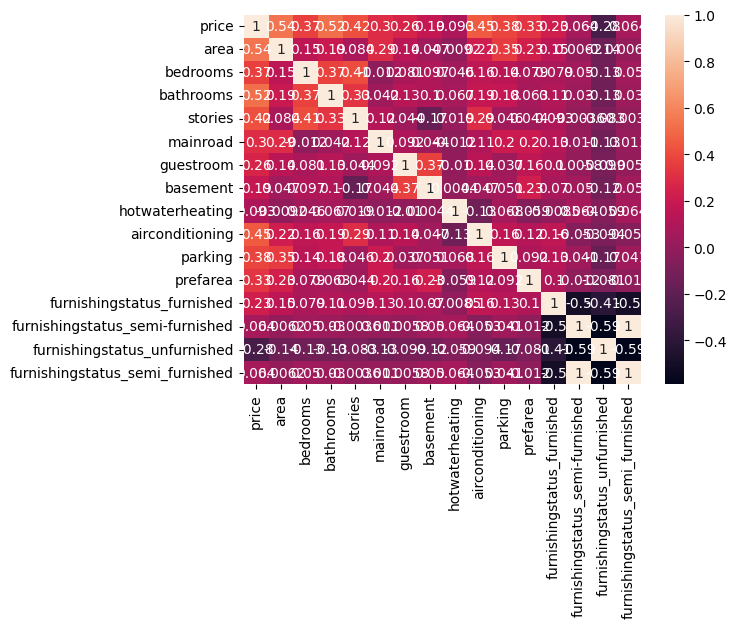

In [40]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [41]:
x=df.drop('price',axis=1)
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
model=LinearRegression()

In [43]:
model.fit(x_train,y_train)

LinearRegression()

In [44]:
model.score(x_test,y_test)

0.6529242642153185

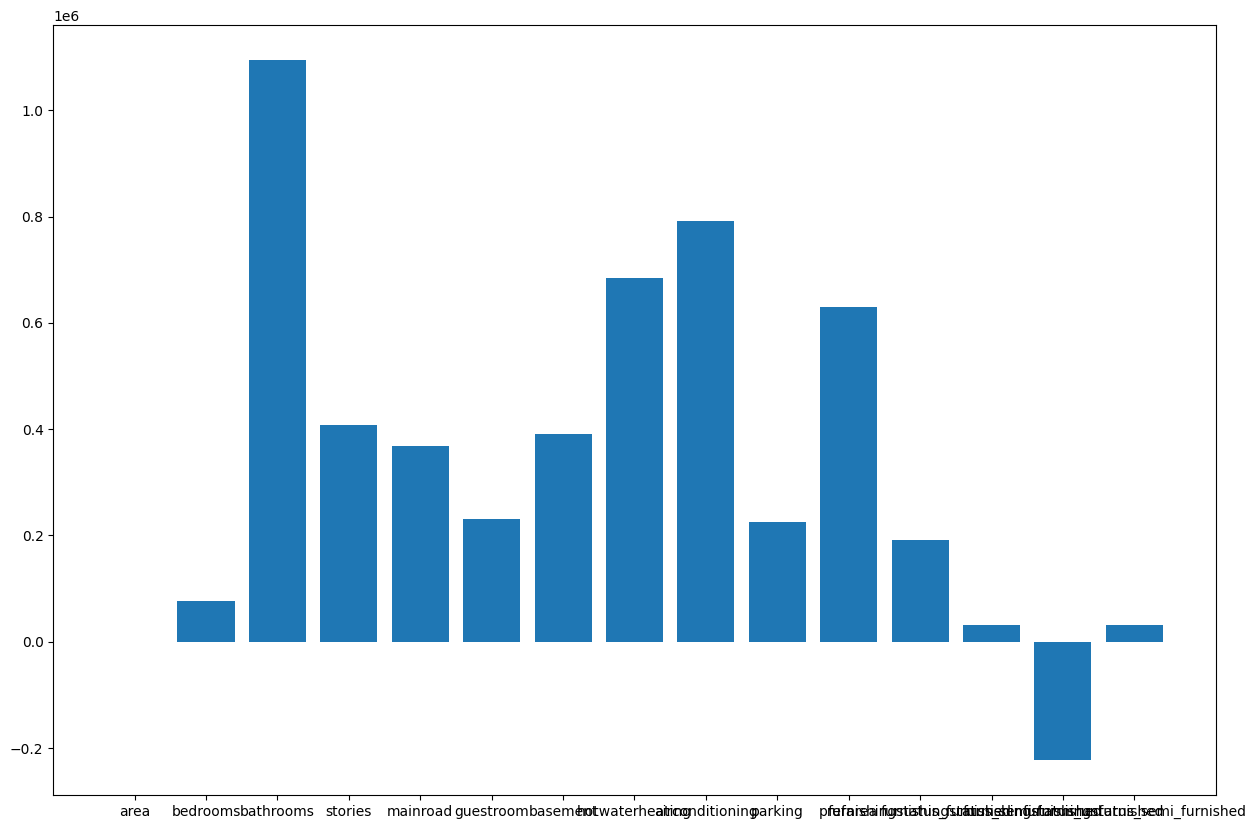

In [46]:
plt.figure(figsize=(15,10))
plt.bar(x.columns,model.coef_)
plt.show()

In [48]:
la=Lasso(alpha=10)
la.fit(x_train,y_train)
la.score(x_test,y_test)

0.6529190590277425

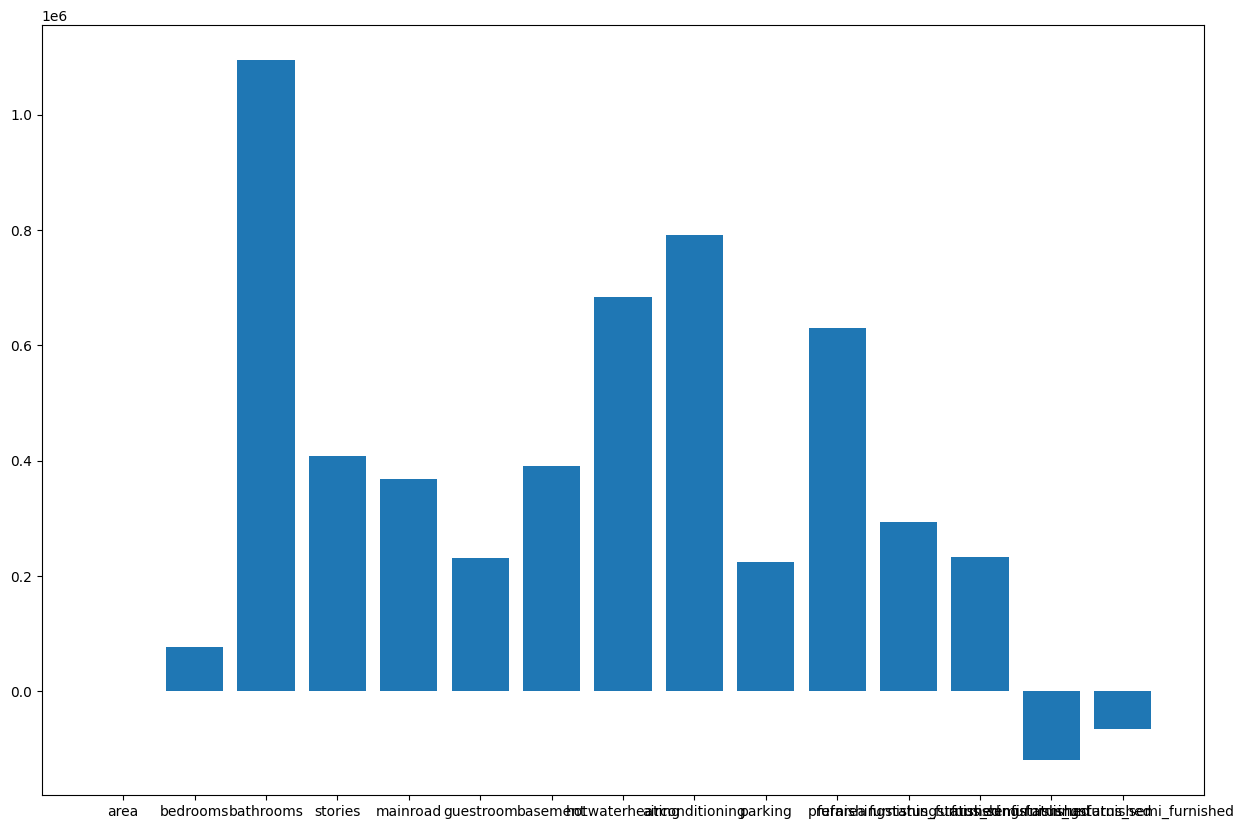

In [49]:
plt.figure(figsize=(15,10))
plt.bar(x.columns,la.coef_)
plt.show()

In [52]:
ri=Ridge(alpha=0.5)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)

0.6526803747444636

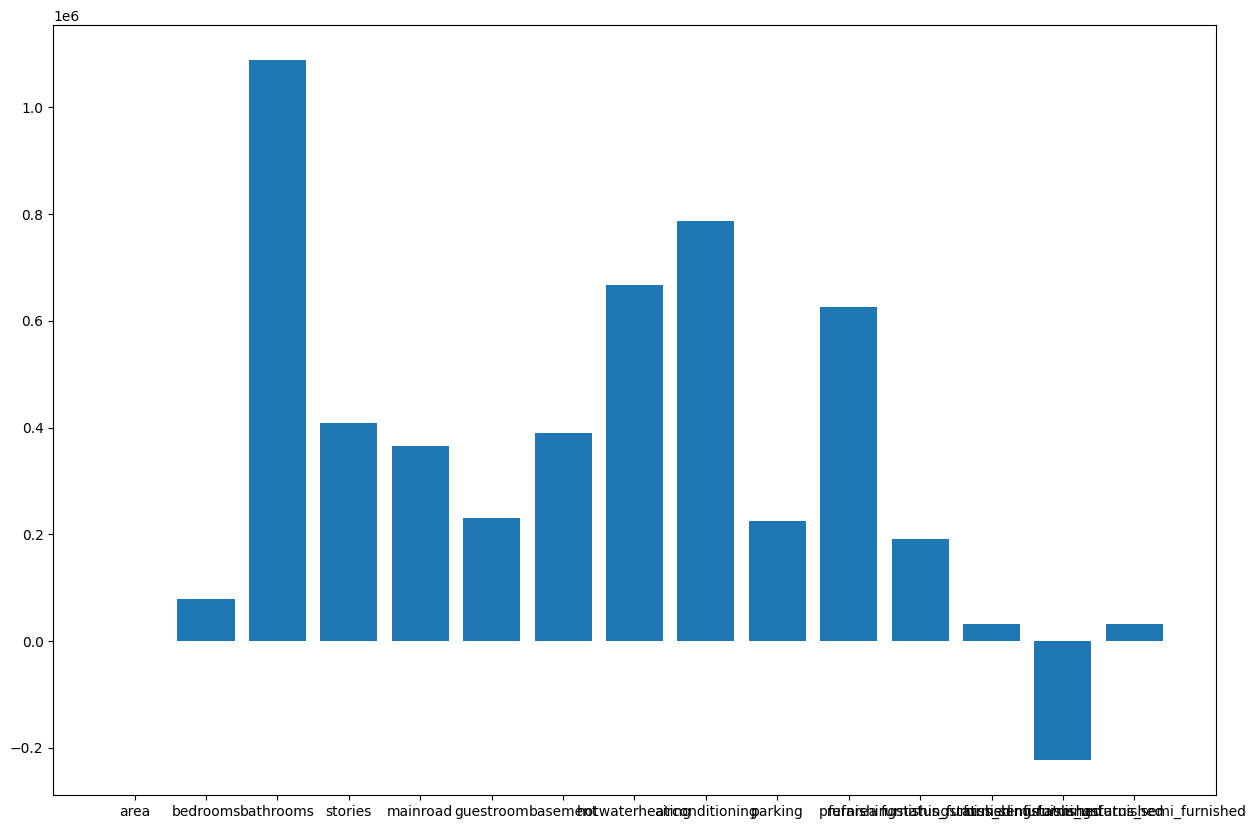

In [53]:
plt.figure(figsize=(15,10))
plt.bar(x.columns,ri.coef_)
plt.show()

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [56]:
print(mean_squared_error(y_test,model.predict(x_test)))
print(mean_absolute_error(y_test,model.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,model.predict(x_test))))

1754318687330.6633
970043.4039201636
1324506.9600914384


In [57]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,la.predict(x_test))))

1754344997316.9114
970050.287149697
1324516.8920466478


In [58]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))

1755551443793.4473
970318.1660853279
1324972.24265018
